## 1 - Project Setup

This notebook answers a question the current test suite (all `step3_test.ipynb`) cannot
answer: **does the "advanced augmentation" (Step 2) training actually pay off in
robustness?** So far every model has only been evaluated on a clean test set, which is
exactly the regime Step 2 does *not* optimize for -- that's why Step 2 models look worse
than Step 1 on the clean set.

Here we evaluate **all 6 architectures (12 checkpoints: Step 1 + Step 2 each)** on both the
clean test set and a **degraded** version of it (JPEG re-compression, Gaussian blur, color
shift), and directly compare accuracy before/after degradation. The degradation parameters
are deliberately **different** from the Step 2 training augmentation (different JPEG
quality, and a blur that was never seen in training) so this measures genuine robustness,
not memorization of the training augmentation recipe.

This section mounts Google Drive (on Colab) or resolves local VM paths, and authenticates
with HuggingFace Hub (needed for the DINOv3 ViT-Small branch).

In [1]:
%pip install -q transformers huggingface_hub accelerate timm

import os
import glob
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import torch
import torch.nn as nn
from huggingface_hub import login
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from transformers import AutoModel
import timm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment setup: works both on Colab (Drive-mounted) and on a local VM/JupyterLab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/internship-deepfake-forensic'
    DATASET_DIR = '/content/dataset'
    MODELS_DIR = os.path.join(DRIVE_ROOT, 'deepfake_models_final')

    if not os.path.exists(DATASET_DIR):
        print("Extracting the dataset... (this might take a few minutes)")
        !unzip -q {os.path.join(DRIVE_ROOT, 'deepfake_dataset.zip')} -d {DATASET_DIR}
        print("Extraction completed!")
    else:
        print("Dataset already present and ready to use!")
else:
    DATA_ROOT = '/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework'
    DATASET_DIR = os.path.join(DATA_ROOT, 'Datasets')
    MODELS_DIR = os.path.join(DATA_ROOT, 'deepfake_models_final')
    print(f"Running outside Colab. Using local paths under: {DATA_ROOT}")

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Dataset directory: {DATASET_DIR}")
print(f"Models directory:  {MODELS_DIR}")

Running outside Colab. Using local paths under: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework
Dataset directory: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/Datasets
Models directory:  /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/deepfake_models_final


In [3]:
# Log in to HuggingFace Hub to access the gated DINOv3 checkpoints
login()

## 2 - Dataset: Clean vs Degraded Test Set

Two `DataLoader`s are built from the same test images: one with the usual clean
`Resize + Normalize` pipeline, and one that additionally applies a **fixed, deterministic**
degradation (no random on/off, no random ranges) so every model in this notebook is
evaluated on the *exact same* degraded images -- a fair, reproducible comparison.

Degradation used (all always-applied, fixed parameters, chosen to differ from Step 2's
training augmentation so this tests real generalization, not memorization):
- Single-pass JPEG re-compression at a harsher fixed quality (58) than Step 2 ever used (Step 2 used quality 60-95).
- Gaussian blur (fixed sigma) -- never seen during training by any model.
- Fixed color shift (brightness/contrast/saturation/hue) -- stronger and deterministic, unlike Step 2's randomized `ColorJitter`.

In [34]:
class Degradation:
    """
    Simulates an image re-shared on the web a couple of times: a random down/up resize
    (screenshot / re-encode at lower resolution) followed by 2-3 JPEG re-compression
    passes at random quality.

    The random draws are seeded from the image's own (post-resize) pixel content, so the
    same image always receives the same degradation on every pass through the loader --
    keeping the comparison across all 12 models fair and reproducible, while still
    varying "randomly" from image to image like real-world re-sharing would.
    """
    def __init__(self, min_passes=2, max_passes=3, min_quality=50, max_quality=85,
                 min_scale=0.5, max_scale=0.85):
        self.min_passes, self.max_passes = min_passes, max_passes
        self.min_quality, self.max_quality = min_quality, max_quality
        self.min_scale, self.max_scale = min_scale, max_scale

    def __call__(self, img):
        import zlib
        rng = random.Random(zlib.crc32(img.tobytes()))
        w, h = img.size

        # Random down/up resize (screenshot / re-share resolution loss)
        scale = rng.uniform(self.min_scale, self.max_scale)
        small = img.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.BICUBIC)
        img = small.resize((w, h), Image.BICUBIC)

        # 2-3 random-quality JPEG re-compression passes
        num_passes = rng.randint(self.min_passes, self.max_passes)
        for _ in range(num_passes):
            quality = rng.randint(self.min_quality, self.max_quality)
            buffer = io.BytesIO()
            img.save(buffer, format="JPEG", quality=quality)
            buffer.seek(0)
            img = Image.open(buffer).convert("RGB")

        return img


# CLEAN test set (same as every step3_test.ipynb)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# DEGRADED test set
degraded_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    Degradation(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 3 - Model Architectures

Re-declares all 6 architectures compared so far, so their checkpoints can be loaded
independently of which notebook originally trained them:

1. `StandardEfficientNet` -- Std EfficientNet-B0
2. `DeiT_Discriminator` -- DeiT-Tiny
3. `HybridDeepfakeDiscriminator` -- Hybrid EfficientNet-B0 (self-attention gated)
4. `DINOv3ConvNeXtClassifier` -- DINOv3 ConvNeXt-Small (frozen backbone)
5. `DualBranchDinoViTClassifier` -- plain EfficientNet-B0 + DINOv3 ViT-Small (CNN+DINO, same cross-attention)
6. `HybridDinoViTClassifier` -- Hybrid EfficientNet-B0 + DINOv3 ViT-Small (cross-attention)

In [35]:
class StandardEfficientNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.model = models.efficientnet_b0(weights=weights)
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


class DeiT_Discriminator(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.model = timm.create_model('deit_tiny_patch16_224', pretrained=pretrained)
        n_features = self.model.head.in_features
        self.model.head = nn.Linear(n_features, num_classes)

    def forward(self, x):
        return self.model(x)


class HybridDeepfakeDiscriminator(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights).features
        in_channels = 1280
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, 1, bias=False),
            nn.BatchNorm2d(in_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, 1, bias=False), nn.Sigmoid()
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4), nn.Linear(in_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features * self.attention(features)
        return self.classifier(torch.flatten(self.pool(features), 1))


class DINOv3ConvNeXtClassifier(nn.Module):
    """
    DINOv3 ConvNeXt-Small as a frozen Foundation-CNN feature extractor, with only a
    lightweight classification head trained on top. The backbone is kept fully frozen
    (see DINOv3_ConvNeXt/step1_baseline.ipynb for the rationale).
    """
    def __init__(self, num_classes=1, model_id="facebook/dinov3-convnext-small-pretrain-lvd1689m"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_id)
        for p in self.backbone.parameters():
            p.requires_grad = False

        hidden_sizes = getattr(self.backbone.config, "hidden_sizes", None)
        hidden_size = hidden_sizes[-1] if hidden_sizes is not None else self.backbone.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(hidden_size, num_classes)
        )

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self

    def state_dict(self, *args, **kwargs):
        return self.classifier.state_dict(*args, **kwargs)

    def load_state_dict(self, state_dict, *args, **kwargs):
        return self.classifier.load_state_dict(state_dict, *args, **kwargs)

    def forward(self, x):
        with torch.no_grad():
            outputs = self.backbone(pixel_values=x)
            features = getattr(outputs, "pooler_output", None)
            if features is None:
                last_hidden = outputs.last_hidden_state
                features = last_hidden.mean(dim=[-2, -1]) if last_hidden.dim() == 4 else last_hidden.mean(dim=1)
        return self.classifier(features)


class CrossAttentionBlock(nn.Module):
    """
    One LSFA-style fusion round: query = DINOv3 tokens, key/value = CNN tokens.
    """
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ffn = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, query_tokens, kv_tokens):
        q = self.norm_q(query_tokens)
        kv = self.norm_kv(kv_tokens)
        attn_out, _ = self.cross_attn(q, kv, kv)
        query_tokens = query_tokens + attn_out
        query_tokens = query_tokens + self.ffn(self.norm_ffn(query_tokens))
        return query_tokens


class HybridDinoViTClassifier(nn.Module):
    """
    Hybrid EfficientNet-B0 (trainable, self-attention gated) + DINOv3 ViT-Small (frozen),
    fused via a stack of cross-attention blocks (the thesis' Proposta Finale).
    """
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280
        self.cnn_attention = nn.Sequential(
            nn.Conv2d(cnn_channels, cnn_channels // 8, 1, bias=False),
            nn.BatchNorm2d(cnn_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(cnn_channels // 8, cnn_channels, 1, bias=False), nn.Sigmoid()
        )

        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)

        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def train(self, mode=True):
        super().train(mode)
        self.dino_backbone.eval()
        return self

    def state_dict(self, *args, **kwargs):
        full = super().state_dict(*args, **kwargs)
        return {k: v for k, v in full.items() if not k.startswith('dino_backbone.')}

    def load_state_dict(self, state_dict, *args, **kwargs):
        return super().load_state_dict(state_dict, *args, strict=False, **kwargs)

    def forward(self, x):
        cnn_features = self.cnn_backbone(x)
        cnn_features = cnn_features * self.cnn_attention(cnn_features)
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)
        cnn_tokens = self.cnn_proj(cnn_tokens)

        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)


class DualBranchDinoViTClassifier(nn.Module):
    """
    CNN + DINOv3 ViT-Small: plain EfficientNet-B0 (no self-attention gating) + DINOv3
    ViT-Small (frozen), fused via the same cross-attention stack as HybridDinoViTClassifier.
    """
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280

        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)

        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def train(self, mode=True):
        super().train(mode)
        self.dino_backbone.eval()
        return self

    def state_dict(self, *args, **kwargs):
        full = super().state_dict(*args, **kwargs)
        return {k: v for k, v in full.items() if not k.startswith('dino_backbone.')}

    def load_state_dict(self, state_dict, *args, **kwargs):
        return super().load_state_dict(state_dict, *args, strict=False, **kwargs)

    def forward(self, x):
        cnn_features = self.cnn_backbone(x)
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)
        cnn_tokens = self.cnn_proj(cnn_tokens)

        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)

## 4 - Data Configuration

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

path_baseline             = os.path.join(MODELS_DIR, 'baseline', 'path')
path_retrain              = os.path.join(MODELS_DIR, 'retrain', 'path')
path_baseline_dino        = os.path.join(MODELS_DIR, 'baseline_dino', 'path')
path_retrain_dino         = os.path.join(MODELS_DIR, 'retrain_dino', 'path')
path_baseline_hybriddino  = os.path.join(MODELS_DIR, 'baseline_hybriddino', 'path')
path_retrain_hybriddino   = os.path.join(MODELS_DIR, 'retrain_hybriddino', 'path')
path_baseline_dualdino    = os.path.join(MODELS_DIR, 'baseline_dualdino', 'path')
path_retrain_dualdino     = os.path.join(MODELS_DIR, 'retrain_dualdino', 'path')
BATCH = 32
NUM_WORKERS = 4

ts_reals = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/test/original/', f'{DATASET_DIR}/CELEBDFV3_DATASET/test/original/']
ts_fakes = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/test/fake/', f'{DATASET_DIR}/CELEBDFV3_DATASET/test/fake/']

# Clean test set (reference)
test_loader = DataLoader(DeepfakeDataset(ts_reals, ts_fakes, test_transforms), BATCH, shuffle=False, num_workers=NUM_WORKERS)

# Degraded test set (same images, deterministic degradation applied)
degraded_test_loader = DataLoader(DeepfakeDataset(ts_reals, ts_fakes, degraded_test_transforms), BATCH, shuffle=False, num_workers=NUM_WORKERS)

print(f"Test set size: {len(test_loader.dataset)} images")

Device in use: cuda
Test set size: 2248 images


## 5 - Load Models

In [37]:
print("Loading all 6 architectures (Step 1 + Step 2 each) for the robustness test...")

#Std EfficientNet-B0
model_std_base = StandardEfficientNet(pretrained=False).to(device)
model_std_base.load_state_dict(torch.load(os.path.join(path_baseline, "std_b0_step1.pth"), map_location=device))
model_std_adv = StandardEfficientNet(pretrained=False).to(device)
model_std_adv.load_state_dict(torch.load(os.path.join(path_retrain, "std_b0_step2.pth"), map_location=device))

#DeiT-Tiny
model_deit_base = DeiT_Discriminator(pretrained=False).to(device)
model_deit_base.load_state_dict(torch.load(os.path.join(path_baseline, "deit_step1.pth"), map_location=device))
model_deit_adv = DeiT_Discriminator(pretrained=False).to(device)
model_deit_adv.load_state_dict(torch.load(os.path.join(path_retrain, "deit_step2.pth"), map_location=device))

#Hybrid EfficientNet-B0
model_hyb_base = HybridDeepfakeDiscriminator(pretrained=False).to(device)
model_hyb_base.load_state_dict(torch.load(os.path.join(path_baseline, "hyb_b0_step1.pth"), map_location=device))
model_hyb_adv = HybridDeepfakeDiscriminator(pretrained=False).to(device)
model_hyb_adv.load_state_dict(torch.load(os.path.join(path_retrain, "hyb_b0_step2.pth"), map_location=device))

#DINOv3 ConvNeXt-Small
model_dino_base = DINOv3ConvNeXtClassifier().to(device)
model_dino_base.load_state_dict(torch.load(os.path.join(path_baseline_dino, "dino_convnext_small_step1.pth"), map_location=device))
model_dino_adv = DINOv3ConvNeXtClassifier().to(device)
model_dino_adv.load_state_dict(torch.load(os.path.join(path_retrain_dino, "dino_convnext_small_step2.pth"), map_location=device))

#Hybrid EfficientNet-B0 + DINOv3 ViT-Small (Proposta Finale)
model_hybriddino_base = HybridDinoViTClassifier().to(device)
model_hybriddino_base.load_state_dict(torch.load(os.path.join(path_baseline_hybriddino, "hybrid_dinovit_step1.pth"), map_location=device))
model_hybriddino_adv = HybridDinoViTClassifier().to(device)
model_hybriddino_adv.load_state_dict(torch.load(os.path.join(path_retrain_hybriddino, "hybrid_dinovit_step2.pth"), map_location=device))

#EfficientNet-B0 (plain) + DINOv3 ViT-Small (CNN+DINO)
model_dualdino_base = DualBranchDinoViTClassifier().to(device)
model_dualdino_base.load_state_dict(torch.load(os.path.join(path_baseline_dualdino, "dual_dinovit_step1.pth"), map_location=device))
model_dualdino_adv = DualBranchDinoViTClassifier().to(device)
model_dualdino_adv.load_state_dict(torch.load(os.path.join(path_retrain_dualdino, "dual_dinovit_step2.pth"), map_location=device))

trained_models = {
    "Std EfficientNet-B0 (Step 1)": model_std_base,
    "Std EfficientNet-B0 (Step 2)": model_std_adv,
    "Deit-Tiny (Step 1)": model_deit_base,
    "Deit-Tiny (Step 2)": model_deit_adv,
    "Hyb EfficientNet-B0 (Step 1)": model_hyb_base,
    "Hyb EfficientNet-B0 (Step 2)": model_hyb_adv,
    "DINOv3 ConvNeXt-S (Step 1)": model_dino_base,
    "DINOv3 ConvNeXt-S (Step 2)": model_dino_adv,
    "CNN+DINOv3 ViT-S (Step 1)": model_dualdino_base,
    "CNN+DINOv3 ViT-S (Step 2)": model_dualdino_adv,
    "Hybrid+DINOv3 ViT-S (Step 1)": model_hybriddino_base,
    "Hybrid+DINOv3 ViT-S (Step 2)": model_hybriddino_adv,
}

print(f"{len(trained_models)} models loaded and ready.")

Loading all 6 architectures (Step 1 + Step 2 each) for the robustness test...


Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

12 models loaded and ready.


## 6 - Test Engine

In [38]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).view(-1)

            probs = torch.sigmoid(outputs)
            preds = (outputs > 0.0).float()

            all_labels.extend(labels.view(-1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_probs), np.array(all_preds)


def evaluate_all(models_dict, loader, device, phase_name):
    """
    Evaluates every model in models_dict on the given loader, prints per-model metrics,
    plots the overlaid ROC curves (scales to any number of models, unlike a per-model
    confusion-matrix grid), and returns a tidy DataFrame with one row per model.
    """
    print(f"\nStarting Quantitative Test for: {phase_name}")
    results = []

    plt.figure(figsize=(8, 7))
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    cmap = plt.colormaps['tab20'].resampled(len(models_dict))

    for i, (name, model) in enumerate(models_dict.items()):
        y_true, y_probs, y_preds = get_all_predictions(model, loader, device)

        acc = accuracy_score(y_true, y_preds)
        f1 = f1_score(y_true, y_preds)
        prec = precision_score(y_true, y_preds)
        rec = recall_score(y_true, y_preds)
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)

        print(f"[{name}] Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | AUC: {roc_auc:.4f}")
        results.append({'Model': name, 'Phase': phase_name, 'Acc': acc, 'F1': f1,
                         'Precision': prec, 'Recall': rec, 'AUC': roc_auc})

        plt.plot(fpr, tpr, color=cmap(i), lw=2, label=f"{name} (AUC: {roc_auc:.3f})")

    plt.title(f"ROC Curves - {phase_name}", fontsize=15, fontweight='bold')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results)

## 7 - Results: Clean vs Degraded

Runs every model on the clean test set (reference) and then on the degraded test set,
under identical conditions in the same notebook run.


Starting Quantitative Test for: Clean Test Set
[Std EfficientNet-B0 (Step 1)] Acc: 0.9662 | F1: 0.9815 | Prec: 0.9975 | Rec: 0.9660 | AUC: 0.9952
[Std EfficientNet-B0 (Step 2)] Acc: 0.8634 | F1: 0.9207 | Prec: 0.9989 | Rec: 0.8538 | AUC: 0.9892
[Deit-Tiny (Step 1)] Acc: 0.7011 | F1: 0.8114 | Prec: 0.9783 | Rec: 0.6932 | AUC: 0.8392
[Deit-Tiny (Step 2)] Acc: 0.7473 | F1: 0.8437 | Prec: 0.9903 | Rec: 0.7349 | AUC: 0.9120
[Hyb EfficientNet-B0 (Step 1)] Acc: 0.9591 | F1: 0.9775 | Prec: 0.9985 | Rec: 0.9573 | AUC: 0.9964
[Hyb EfficientNet-B0 (Step 2)] Acc: 0.8541 | F1: 0.9147 | Prec: 0.9994 | Rec: 0.8432 | AUC: 0.9901
[DINOv3 ConvNeXt-S (Step 1)] Acc: 0.6357 | F1: 0.7599 | Prec: 0.9781 | Rec: 0.6213 | AUC: 0.8125
[DINOv3 ConvNeXt-S (Step 2)] Acc: 0.7126 | F1: 0.8210 | Prec: 0.9731 | Rec: 0.7100 | AUC: 0.8158
[CNN+DINOv3 ViT-S (Step 1)] Acc: 0.7629 | F1: 0.8535 | Prec: 1.0000 | Rec: 0.7445 | AUC: 0.9941
[CNN+DINOv3 ViT-S (Step 2)] Acc: 0.8296 | F1: 0.8991 | Prec: 0.9982 | Rec: 0.8178 | AUC:

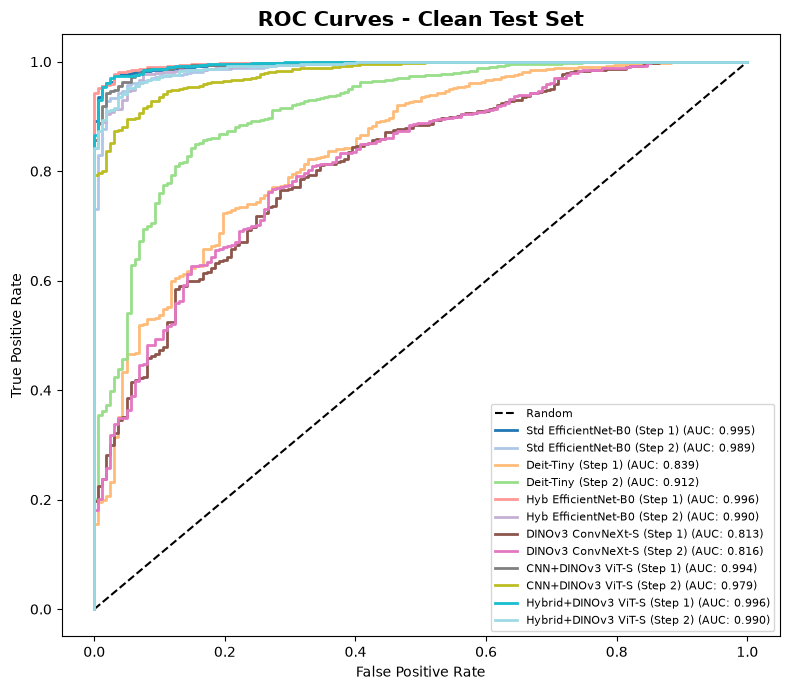

In [39]:
clean_results = evaluate_all(trained_models, test_loader, device, "Clean Test Set")


Starting Quantitative Test for: Degraded Test Set (JPEG q50-85 x2-3 passes + Resize)
[Std EfficientNet-B0 (Step 1)] Acc: 0.5018 | F1: 0.6368 | Prec: 0.9840 | Rec: 0.4708 | AUC: 0.8311
[Std EfficientNet-B0 (Step 2)] Acc: 0.5774 | F1: 0.7064 | Prec: 0.9939 | Rec: 0.5479 | AUC: 0.8977
[Deit-Tiny (Step 1)] Acc: 0.4800 | F1: 0.6153 | Prec: 0.9811 | Rec: 0.4482 | AUC: 0.7854
[Deit-Tiny (Step 2)] Acc: 0.4942 | F1: 0.6283 | Prec: 0.9877 | Rec: 0.4607 | AUC: 0.8656
[Hyb EfficientNet-B0 (Step 1)] Acc: 0.6090 | F1: 0.7339 | Prec: 0.9959 | Rec: 0.5810 | AUC: 0.8767
[Hyb EfficientNet-B0 (Step 2)] Acc: 0.7042 | F1: 0.8118 | Prec: 0.9910 | Rec: 0.6874 | AUC: 0.9197
[DINOv3 ConvNeXt-S (Step 1)] Acc: 0.1655 | F1: 0.1872 | Prec: 0.9730 | Rec: 0.1035 | AUC: 0.6756
[DINOv3 ConvNeXt-S (Step 2)] Acc: 0.2349 | F1: 0.3087 | Prec: 0.9552 | Rec: 0.1841 | AUC: 0.6883
[CNN+DINOv3 ViT-S (Step 1)] Acc: 0.4159 | F1: 0.5414 | Prec: 0.9974 | Rec: 0.3715 | AUC: 0.8773
[CNN+DINOv3 ViT-S (Step 2)] Acc: 0.6779 | F1: 0.79

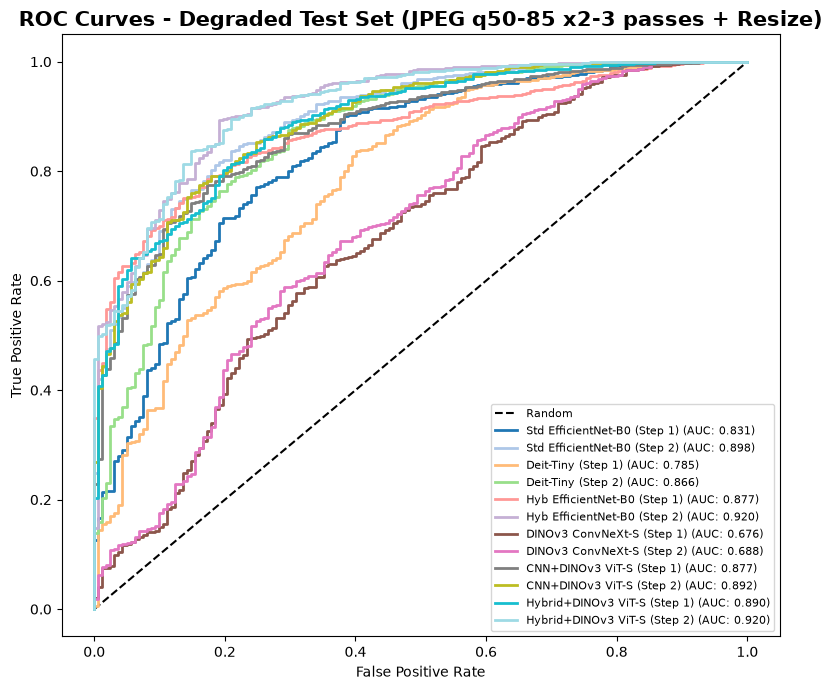

In [40]:
degraded_results = evaluate_all(trained_models, degraded_test_loader, device, "Degraded Test Set")

## 8 - Step 1 vs Step 2 (Degraded Test Set)

       Architecture   Step 1   Step 2    Delta
   CNN+DINOv3 ViT-S 0.415925 0.677936 0.262011
Hybrid+DINOv3 ViT-S 0.597865 0.695730 0.097865
Hyb EfficientNet-B0 0.608986 0.704181 0.095196
Std EfficientNet-B0 0.501779 0.577402 0.075623
  DINOv3 ConvNeXt-S 0.165480 0.234875 0.069395
          Deit-Tiny 0.479982 0.494217 0.014235


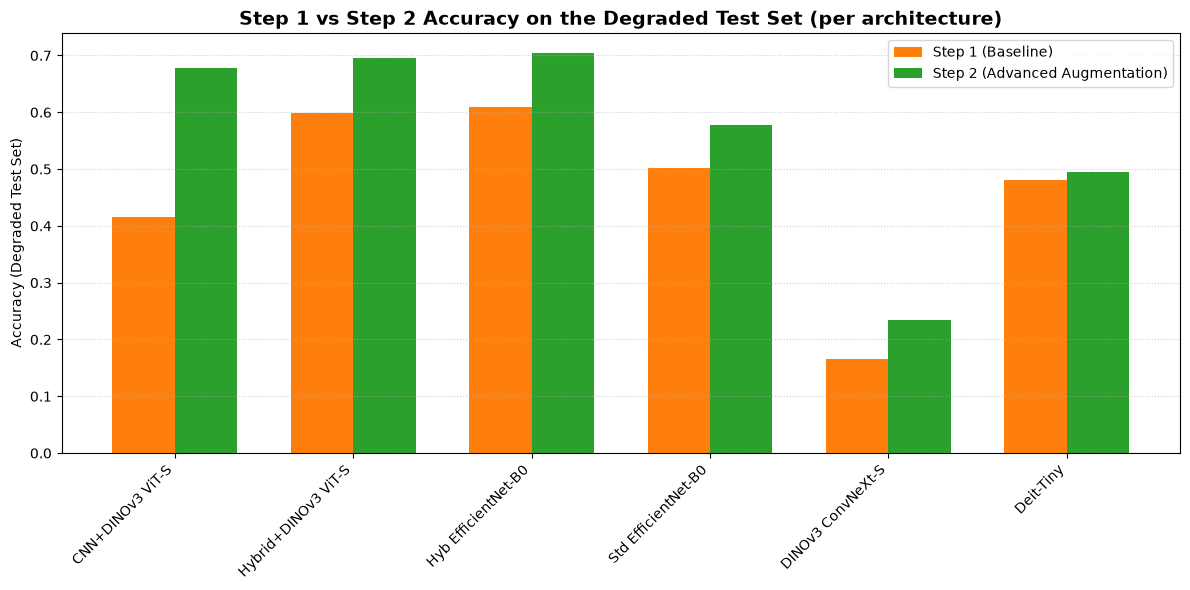

In [41]:
degraded_results['Architecture'] = degraded_results['Model'].str.replace(r' \(Step \d\)', '', regex=True)
degraded_results['Step'] = degraded_results['Model'].apply(lambda n: 'Step 1' if 'Step 1' in n else 'Step 2')

step_comparison = degraded_results.pivot(index='Architecture', columns='Step', values='Acc').reset_index()
step_comparison['Delta'] = step_comparison['Step 2'] - step_comparison['Step 1']
step_comparison = step_comparison.sort_values('Delta', ascending=False).reset_index(drop=True)
print(step_comparison.to_string(index=False))

x = np.arange(len(step_comparison))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, step_comparison['Step 1'], width, label='Step 1 (Baseline)', color='#ff7f0e')
ax.bar(x + width / 2, step_comparison['Step 2'], width, label='Step 2 (Advanced Augmentation)', color='#2ca02c')
ax.set_xticks(x)
ax.set_xticklabels(step_comparison['Architecture'], rotation=45, ha='right')
ax.set_ylabel('Accuracy (Degraded Test Set)')
ax.set_title('Step 1 vs Step 2 Accuracy on the Degraded Test Set (per architecture)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

curves_path = os.path.join(MODELS_DIR, 'robustness_test')
os.makedirs(curves_path, exist_ok=True)
plt.savefig(os.path.join(curves_path, 'step1_vs_step2_degraded_accuracy.png'), dpi=300, bbox_inches='tight')
plt.show()

## 9 - Robustness Summary (Clean vs Degraded)

       Architecture  Clean (S1)  Clean (S2)  Degraded (S1)  Degraded (S2)  Degraded Gain (S1->S2)
   CNN+DINOv3 ViT-S    0.762900    0.829626       0.415925       0.677936                0.262011
Hybrid+DINOv3 ViT-S    0.962189    0.899911       0.597865       0.695730                0.097865
Hyb EfficientNet-B0    0.959075    0.854093       0.608986       0.704181                0.095196
Std EfficientNet-B0    0.966192    0.863434       0.501779       0.577402                0.075623
  DINOv3 ConvNeXt-S    0.635676    0.712633       0.165480       0.234875                0.069395
          Deit-Tiny    0.701068    0.747331       0.479982       0.494217                0.014235


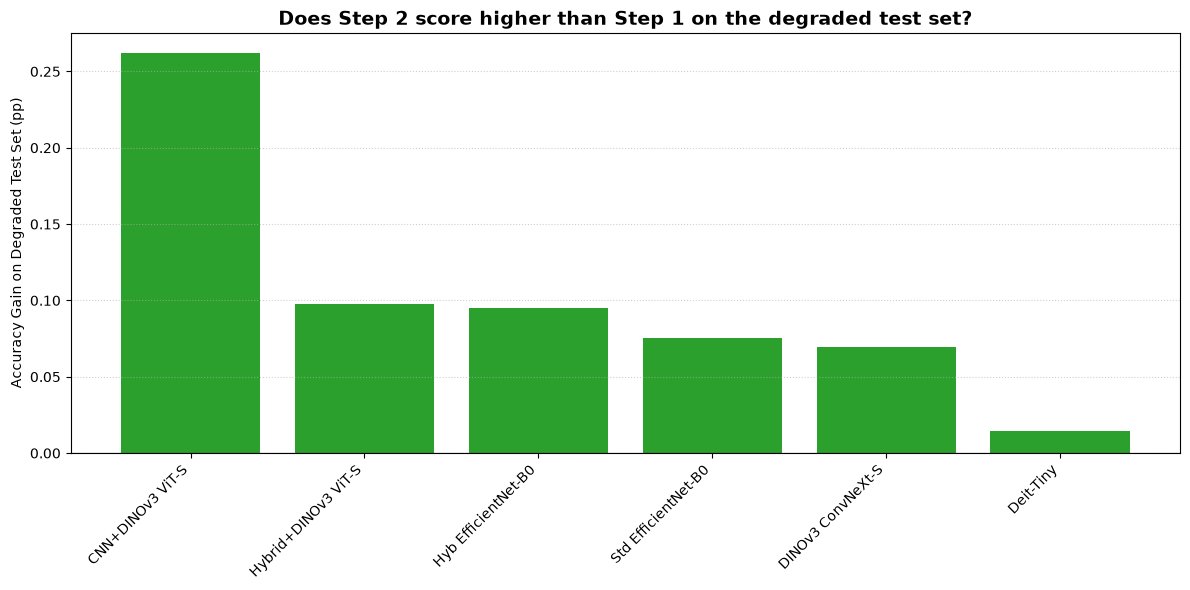

In [42]:
comparison = clean_results[['Model', 'Acc']].merge(
    degraded_results[['Model', 'Acc']], on='Model', suffixes=(' (Clean)', ' (Degraded)')
)
comparison['Delta'] = comparison['Acc (Degraded)'] - comparison['Acc (Clean)']
comparison['Architecture'] = comparison['Model'].str.replace(r' \(Step \d\)', '', regex=True)
comparison['Step'] = comparison['Model'].apply(lambda n: 'Step 1' if 'Step 1' in n else 'Step 2')

pivoted = comparison.pivot(index='Architecture', columns='Step', values=['Acc (Clean)', 'Acc (Degraded)'])
pivoted.columns = [f'{metric} {step}' for metric, step in pivoted.columns]
pivoted = pivoted.reset_index()

pivoted['Degraded Gain (S1->S2)'] = pivoted['Acc (Degraded) Step 2'] - pivoted['Acc (Degraded) Step 1']
pivoted = pivoted.sort_values('Degraded Gain (S1->S2)', ascending=False).reset_index(drop=True)

table = pivoted[['Architecture', 'Acc (Clean) Step 1', 'Acc (Clean) Step 2',
                  'Acc (Degraded) Step 1', 'Acc (Degraded) Step 2', 'Degraded Gain (S1->S2)']]
table.columns = ['Architecture', 'Clean (S1)', 'Clean (S2)', 'Degraded (S1)', 'Degraded (S2)', 'Degraded Gain (S1->S2)']
print(table.to_string(index=False))

x = np.arange(len(table))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in table['Degraded Gain (S1->S2)']]
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x, table['Degraded Gain (S1->S2)'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(table['Architecture'], rotation=45, ha='right')
ax.set_ylabel('Accuracy Gain on Degraded Test Set (pp)')
ax.set_title('Does Step 2 score higher than Step 1 on the degraded test set?', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

curves_path = os.path.join(MODELS_DIR, 'robustness_test')
os.makedirs(curves_path, exist_ok=True)
plt.savefig(os.path.join(curves_path, 'degraded_gain_per_architecture.png'), dpi=300, bbox_inches='tight')
plt.show()